# Parameter Estimation Recitation

This notebook focuses on the **difference in meaning** among:

- Maximum Likelihood Estimation (MLE)
- Maximum A Posteriori (MAP)
- Full Bayesian Estimation

The examples are intentionally chosen so that the methods can give **visibly different results**.

**Colors used in every plot**

| color | what it shows |
|---|---|
| blue | likelihood $p(D\mid\theta)$ and the **MLE** |
| aqua | prior $p(\theta)$ |
| violet | posterior $p(\theta\mid D)$ and **full-Bayes** quantities: posterior mean, credible interval, predictive |
| orange | **MAP**: a single point, the peak of the posterior |

Vertical lines: MLE dashed, MAP dotted, posterior mean dash-dot.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, beta, binom, betabinom

# Animations are embedded as a JavaScript player (play / pause / slider),
# so they run in Jupyter and VS Code and stay in the saved notebook.
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Large figures: 10 inches wide at 120 dpi; panels are stacked vertically
# so that each one uses the full width of the cell.
plt.rcParams.update({"figure.figsize": (10, 6), "figure.dpi": 120,
                     "font.size": 12, "legend.fontsize": 11,
                     "axes.grid": True, "grid.alpha": 0.3})
plt.rcParams["animation.embed_limit"] = 60   # MB per animation

# One color per idea, used in every plot (see the table above)
COL_MLE = "#2a78d6"     # blue:   likelihood and MLE
COL_PRIOR = "#1baf7a"   # aqua:   prior
COL_POST = "#4a3aa7"    # violet: posterior and full-Bayes quantities
COL_MAP = "#eb6834"     # orange: MAP


def show_animation(fig, update, frames, interval=150):
    anim = FuncAnimation(fig, update, frames=frames, interval=interval)
    plt.close(fig)                            # avoid an extra static copy
    # Frames are saved at 100 dpi to keep the notebook small; max-width lets
    # the player shrink to the cell width, like the static figures do.
    with plt.rc_context({"savefig.dpi": 100}):
        html = anim.to_jshtml(default_mode="reflect")
    return HTML(html.replace("<img id=", '<img style="max-width: 100%" id='))

## 1. Three different questions

### MLE

$$
\hat{\theta}_{ML}
=
\arg\max_{\theta} p(D\mid\theta)
$$

MLE asks:

> Which parameter value makes the observed data most likely?

It uses the **likelihood only**.

---

### MAP

$$
\hat{\theta}_{MAP}
=
\arg\max_{\theta} p(\theta\mid D)
$$

and

$$
p(\theta\mid D)
\propto
p(D\mid\theta)p(\theta).
$$

MAP asks:

> After combining the data with the prior, which parameter value is most probable?

It returns a **single point**.

---

### Bayesian estimation

Bayesian estimation keeps

$$
p(\theta\mid D)
$$

rather than reducing the posterior to one point.

For prediction,

$$
p(x_{new}\mid D)
=
\int
p(x_{new}\mid\theta)
p(\theta\mid D)
\,d\theta.
$$

So the central distinction is:

$$
\boxed{\text{MLE: likelihood}}
$$

$$
\boxed{\text{MAP: posterior mode}}
$$

$$
\boxed{\text{Bayes: full posterior}}
$$

## 2. Gaussian example: MLE and MAP can be very different

Assume

$$
x_i \sim \mathcal{N}(\mu,\sigma^2)
$$

with known

$$
\sigma=1.5.
$$

Observed data:

$$
D=\{9,10,11\}.
$$

The sample mean is 10, so MLE strongly favors a mean near 10.

Now suppose the prior is

$$
\mu\sim\mathcal{N}(4,0.5^2).
$$

This prior strongly favors a value near 4.

The data and prior intentionally disagree.

In [2]:
# Observed data
data = np.array([9.0, 10.0, 11.0])

# Known observation standard deviation
sigma = 1.5

# Gaussian prior
mu0 = 4.0
sigma0 = 0.5

n = len(data)
x_bar = data.mean()

# MLE for Gaussian mean with known variance
mu_mle = x_bar

# Gaussian posterior
posterior_var = 1.0 / (n / sigma**2 + 1.0 / sigma0**2)
posterior_std = np.sqrt(posterior_var)

posterior_mean = posterior_var * (
    n * x_bar / sigma**2
    + mu0 / sigma0**2
)

# For a Gaussian posterior, mode = mean
mu_map = posterior_mean

print(f"sample mean  = {x_bar:.3f}")
print(f"MLE          = {mu_mle:.3f}")
print(f"prior mean   = {mu0:.3f}")
print(f"MAP          = {mu_map:.3f}")
print(f"posterior SD = {posterior_std:.3f}")

sample mean  = 10.000
MLE          = 10.000
prior mean   = 4.000
MAP          = 5.500
posterior SD = 0.433


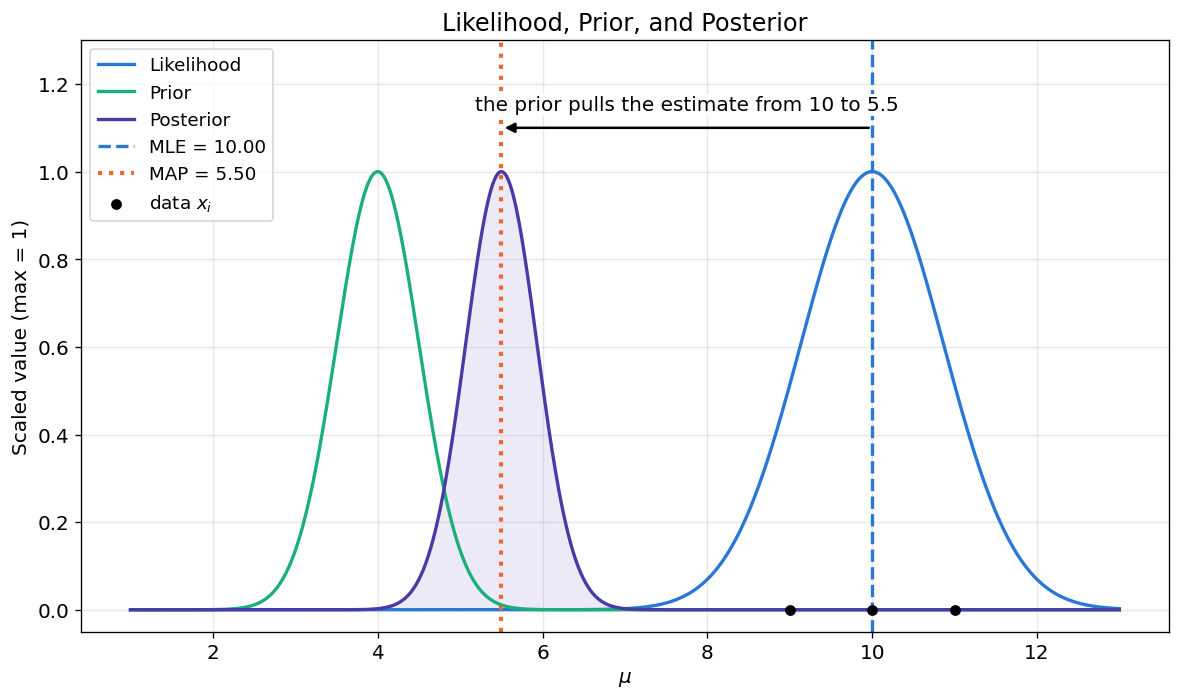

In [3]:
# Parameter grid
mu_grid = np.linspace(1, 13, 1200)

# Likelihood p(D | mu)
log_likelihood = np.array([
    np.sum(norm.logpdf(data, loc=mu, scale=sigma))
    for mu in mu_grid
])

# Relative likelihood for plotting
likelihood = np.exp(log_likelihood - np.max(log_likelihood))

# Prior p(mu)
prior = norm.pdf(mu_grid, loc=mu0, scale=sigma0)

# Posterior p(mu | D)
posterior = norm.pdf(
    mu_grid,
    loc=posterior_mean,
    scale=posterior_std
)

# Scale each curve only for visual comparison
likelihood_plot = likelihood / likelihood.max()
prior_plot = prior / prior.max()
posterior_plot = posterior / posterior.max()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(mu_grid, likelihood_plot, color=COL_MLE, linewidth=2, label="Likelihood")
ax.plot(mu_grid, prior_plot, color=COL_PRIOR, linewidth=2, label="Prior")
ax.plot(mu_grid, posterior_plot, color=COL_POST, linewidth=2, label="Posterior")
ax.fill_between(mu_grid, posterior_plot, color=COL_POST, alpha=0.1)

ax.axvline(mu_mle, color=COL_MLE, linestyle="--", linewidth=2, label=f"MLE = {mu_mle:.2f}")
ax.axvline(mu_map, color=COL_MAP, linestyle=":", linewidth=2.5, label=f"MAP = {mu_map:.2f}")

# The data themselves, on the same axis
ax.scatter(data, np.zeros_like(data), color="k", s=30, zorder=4, label="data $x_i$")

# The prior pulls the estimate away from the data
ax.annotate("", xy=(mu_map, 1.1), xytext=(mu_mle, 1.1),
            arrowprops=dict(arrowstyle="-|>", color="k", lw=1.5))
ax.text((mu_map + mu_mle) / 2, 1.14, "the prior pulls the estimate from 10 to 5.5",
        ha="center", bbox=dict(fc="white", ec="none", pad=1))

ax.set_ylim(-0.05, 1.3)
ax.set_xlabel(r"$\mu$")
ax.set_ylabel("Scaled value (max = 1)")
ax.set_title("Likelihood, Prior, and Posterior")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

For this example,

$$
\hat{\mu}_{ML}=10
$$

but

$$
\hat{\mu}_{MAP}=5.5.
$$

The difference is large because:

- there are only a few observations;
- the prior is strong;
- the prior and the data disagree.

So MAP is **not** simply another name for MLE.

### 2.1 In log form, MAP is MLE plus a penalty

Taking the log turns the product $p(D\mid\mu)\,p(\mu)$ into a sum:

$$
\hat{\mu}_{MAP}
=\arg\max_{\mu}\Big[\underbrace{\log p(D\mid\mu)}_{\text{fit to the data}}
+\underbrace{\log p(\mu)}_{-\text{penalty}}\Big],
\qquad
-\log p(\mu)=\frac{(\mu-\mu_0)^2}{2\sigma_0^2}+\text{const}.
$$

The penalty grows as $\mu$ moves away from $\mu_0$. This is the same idea as L2 regularization (ridge regression, weight decay): a Gaussian prior on the parameters.

For a Gaussian likelihood and a Gaussian prior, the maximizer is a **precision-weighted average** (precision = 1 / variance):

$$
\hat{\mu}_{MAP}
=\frac{\frac{n}{\sigma^2}\,\bar{x}+\frac{1}{\sigma_0^2}\,\mu_0}{\frac{n}{\sigma^2}+\frac{1}{\sigma_0^2}}
=\frac{1.33\cdot 10+4\cdot 4}{1.33+4}
=0.25\cdot 10+0.75\cdot 4=5.5 .
$$

The prior is three times as precise as the three observations together, so it gets three times the weight.

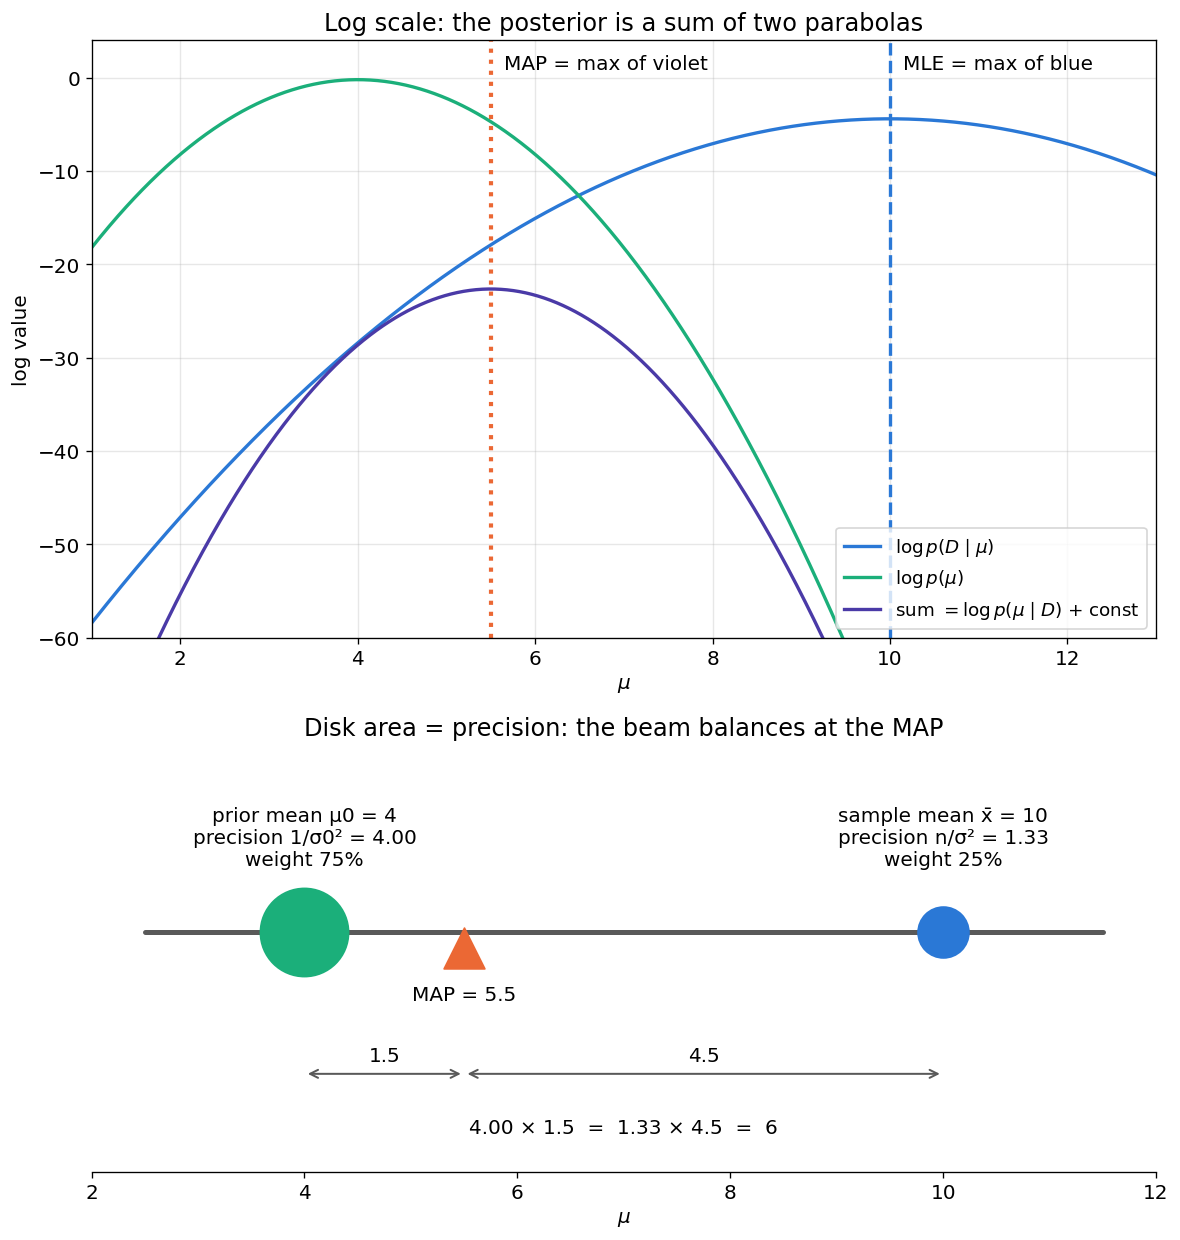

In [4]:
# Log view: log posterior = log likelihood + log prior + const
log_prior_grid = norm.logpdf(mu_grid, mu0, sigma0)
log_post_unnorm = log_likelihood + log_prior_grid

fig, (ax_log, ax_bal) = plt.subplots(2, 1, figsize=(10, 10.5),
                                     gridspec_kw={"height_ratios": [1.4, 1]})

ax_log.plot(mu_grid, log_likelihood, color=COL_MLE, linewidth=2,
            label=r"$\log p(D\mid\mu)$")
ax_log.plot(mu_grid, log_prior_grid, color=COL_PRIOR, linewidth=2,
            label=r"$\log p(\mu)$")
ax_log.plot(mu_grid, log_post_unnorm, color=COL_POST, linewidth=2,
            label=r"sum $=\log p(\mu\mid D)$ + const")
ax_log.axvline(mu_mle, color=COL_MLE, linestyle="--", linewidth=2)
ax_log.axvline(mu_map, color=COL_MAP, linestyle=":", linewidth=2.5)
ax_log.text(mu_mle + 0.15, 2.5, "MLE = max of blue", va="top")
ax_log.text(mu_map + 0.15, 2.5, "MAP = max of violet", va="top")
ax_log.set_xlim(1, 13)
ax_log.set_ylim(-60, 4)
ax_log.set_xlabel(r"$\mu$")
ax_log.set_ylabel("log value")
ax_log.set_title("Log scale: the posterior is a sum of two parabolas")
ax_log.legend(loc="lower right")

# Balance: MAP is the point where the two precisions balance
prec_data = n / sigma**2            # precision of the sample mean
prec_prior = 1 / sigma0**2          # precision of the prior
w_data = prec_data / (prec_data + prec_prior)

ax_bal.plot([2.5, 11.5], [0, 0], color="0.35", linewidth=3, solid_capstyle="round")
ax_bal.scatter([mu0], [0], s=700 * prec_prior, color=COL_PRIOR, zorder=3)
ax_bal.scatter([x_bar], [0], s=700 * prec_data, color=COL_MLE, zorder=3)
ax_bal.scatter([mu_map], [-0.09], marker="^", s=600, color=COL_MAP, zorder=3)
ax_bal.text(mu0, 0.35, f"prior mean μ0 = {mu0:g}\nprecision 1/σ0² = {prec_prior:.2f}\n"
            f"weight {1 - w_data:.0%}", ha="center", va="bottom")
ax_bal.text(x_bar, 0.35, f"sample mean x̄ = {x_bar:g}\nprecision n/σ² = {prec_data:.2f}\n"
            f"weight {w_data:.0%}", ha="center", va="bottom")
ax_bal.text(mu_map, -0.3, f"MAP = {mu_map:g}", ha="center", va="top")

# Lever rule: precision x distance is the same on both sides
y_arm = -0.8
for left, right in [(mu0, mu_map), (mu_map, x_bar)]:
    ax_bal.annotate("", xy=(left, y_arm), xytext=(right, y_arm),
                    arrowprops=dict(arrowstyle="<->", color="0.35", lw=1.2))
    ax_bal.text((left + right) / 2, y_arm + 0.05, f"{right - left:g}", ha="center", va="bottom")
ax_bal.text(7, -1.05, f"{prec_prior:.2f} × {mu_map - mu0:g}  =  {prec_data:.2f} × {x_bar - mu_map:g}"
            f"  =  {prec_prior * (mu_map - mu0):.0f}", ha="center", va="top")
ax_bal.set_xlim(2, 12)
ax_bal.set_ylim(-1.35, 1.05)
ax_bal.set_yticks([])
ax_bal.grid(False)
for side in ["left", "right", "top"]:
    ax_bal.spines[side].set_visible(False)
ax_bal.set_xlabel(r"$\mu$")
ax_bal.set_title("Disk area = precision: the beam balances at the MAP")

plt.tight_layout()
plt.show()

## 3. Why can MAP become close to MLE?

The influence of the prior shrinks in two ways: the prior becomes **weaker** (3.1), or the data become **more numerous** (3.2).

### 3.1 A weaker prior

Keep the same data and prior mean, but increase the prior variance.

A large prior variance means that the prior is less informative.

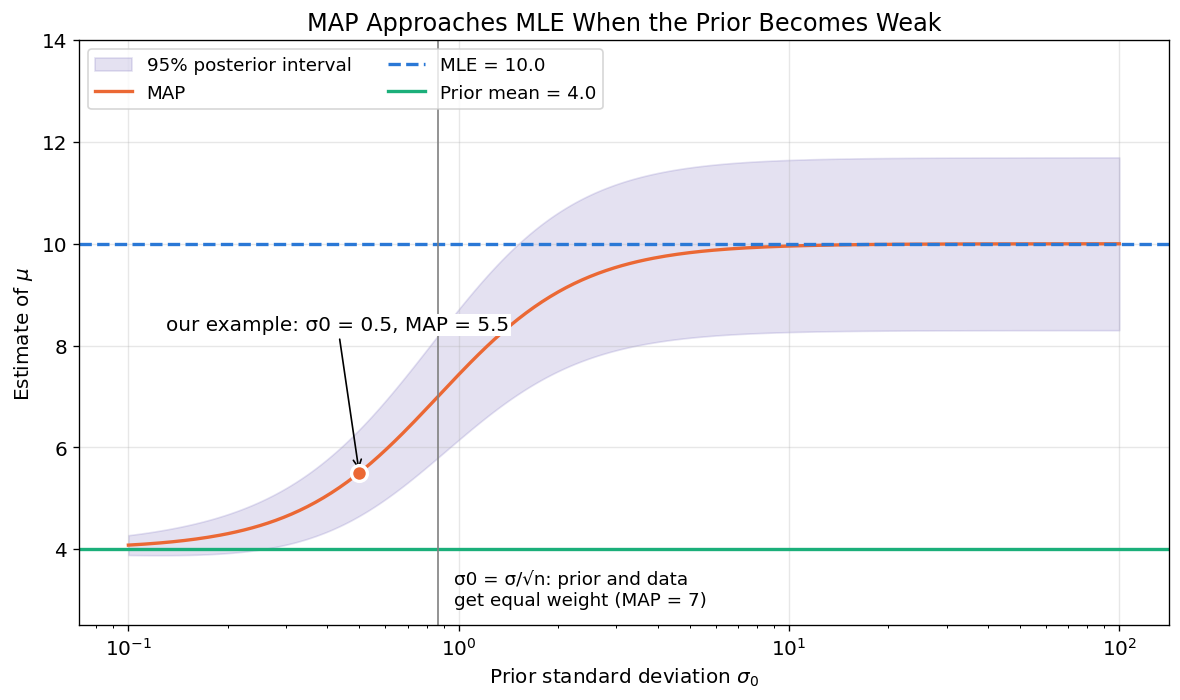

In [5]:
prior_std_values = np.logspace(-1, 2, 250)
map_values = []
post_sd_values = []

for s0 in prior_std_values:
    post_var = 1.0 / (n / sigma**2 + 1.0 / s0**2)
    post_mean = post_var * (
        n * x_bar / sigma**2
        + mu0 / s0**2
    )
    map_values.append(post_mean)
    post_sd_values.append(np.sqrt(post_var))

map_values = np.array(map_values)
post_sd_values = np.array(post_sd_values)

fig, ax = plt.subplots(figsize=(10, 6))
# Full Bayes keeps a whole interval, not only the MAP point
ax.fill_between(prior_std_values,
                map_values - 1.96 * post_sd_values,
                map_values + 1.96 * post_sd_values,
                color=COL_POST, alpha=0.15, label="95% posterior interval")
ax.plot(prior_std_values, map_values, color=COL_MAP, linewidth=2, label="MAP")
ax.axhline(mu_mle, color=COL_MLE, linestyle="--", linewidth=2, label=f"MLE = {mu_mle:.1f}")
ax.axhline(mu0, color=COL_PRIOR, linewidth=2, label=f"Prior mean = {mu0:.1f}")

# Our example, and the prior SD at which prior and data get equal weight
ax.scatter([sigma0], [mu_map], s=90, color=COL_MAP, edgecolor="white", linewidth=2, zorder=4)
ax.annotate(f"our example: σ0 = {sigma0}, MAP = {mu_map:.1f}", xy=(sigma0, mu_map),
            xytext=(0.13, 8.3), arrowprops=dict(arrowstyle="->", color="k"),
            bbox=dict(fc="white", ec="none", pad=1))
s_equal = sigma / np.sqrt(n)
ax.axvline(s_equal, color="0.5", linewidth=1)
ax.text(s_equal * 1.12, 2.9, "σ0 = σ/√n: prior and data\nget equal weight (MAP = 7)", fontsize=11)

ax.set_xscale("log")
ax.set_ylim(2.5, 14)
ax.set_xlabel(r"Prior standard deviation $\sigma_0$")
ax.set_ylabel(r"Estimate of $\mu$")
ax.set_title("MAP Approaches MLE When the Prior Becomes Weak")
ax.legend(loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

This plot explains an important point:

$$
\text{MAP}\approx\text{MLE}
$$

can happen, but only when the prior has little influence.

That numerical similarity should not hide their conceptual difference.

### 3.2 More data also overwhelm the prior

Keep the prior $\mathcal{N}(4,0.5^2)$, but keep collecting data: the three observations above, then more draws from $\mathcal{N}(10,1.5^2)$.

For this model the MAP can be written as

$$
\hat{\mu}_{MAP}
=\frac{n\,\bar{x}+m\,\mu_0}{n+m},
\qquad
m=\frac{\sigma^2}{\sigma_0^2}=\frac{1.5^2}{0.5^2}=9 .
$$

So the prior acts like **$m=9$ extra observations, all equal to $\mu_0=4$**. With $n=3$ real observations the prior wins: $(3\cdot 10+9\cdot 4)/12=5.5$. Once $n\gg 9$, the real data dominate and $\hat{\mu}_{MAP}\to\hat{\mu}_{ML}$.

The posterior also becomes narrower as $n$ grows: for large $n$, MLE and MAP are practically the same number, but only the posterior says *how sure* we are (the violet band).

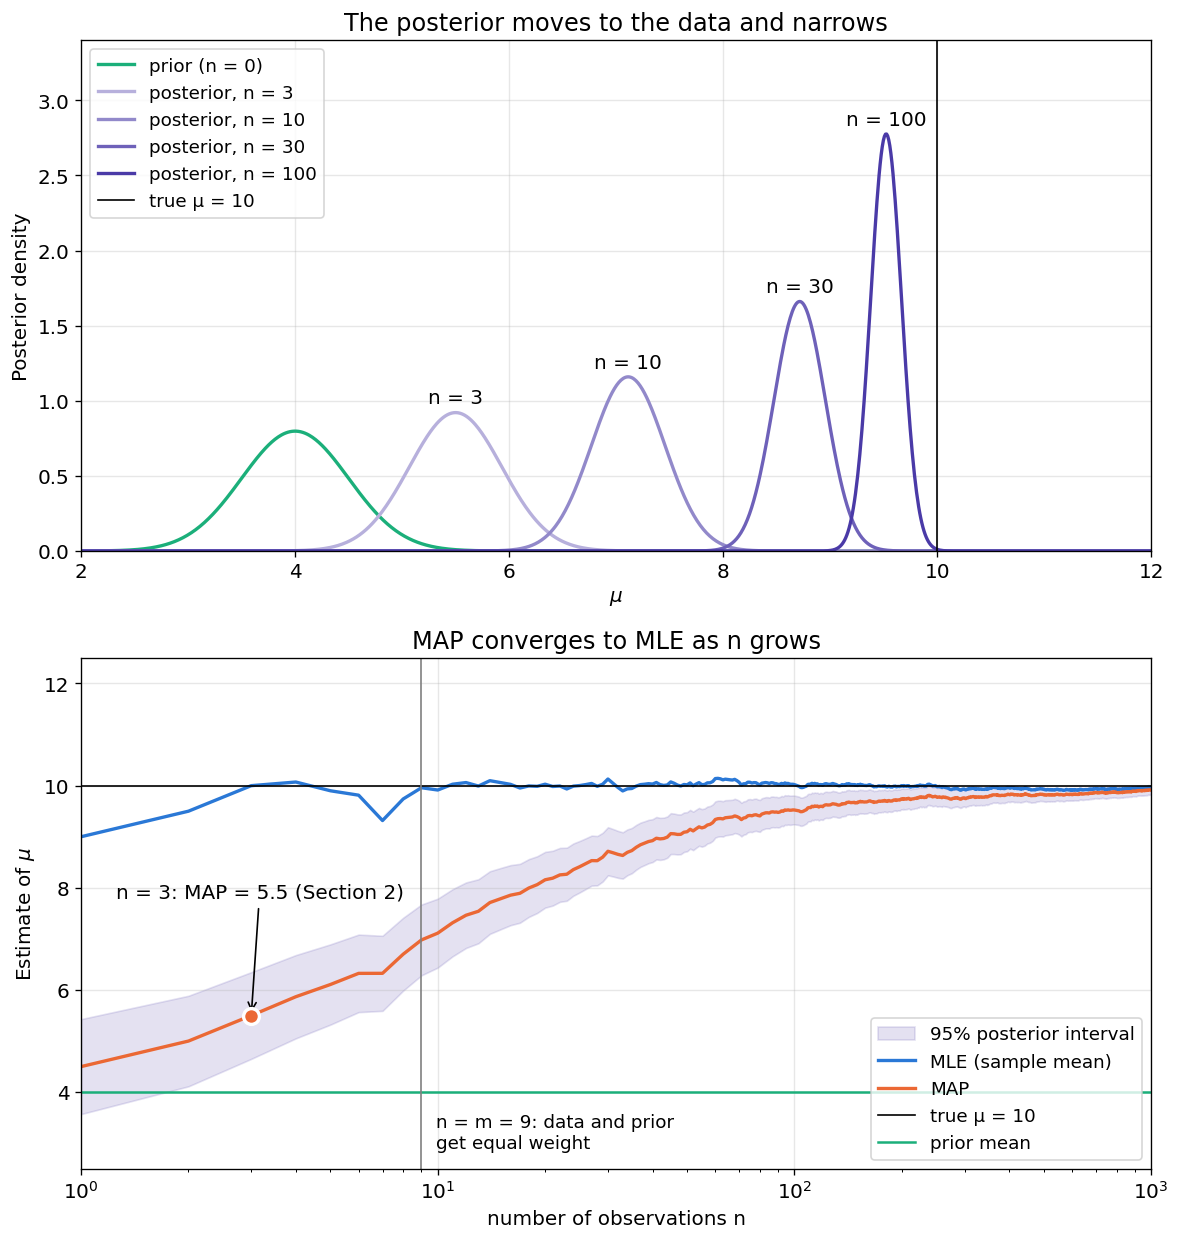

In [6]:
from matplotlib.colors import to_rgb

# A data stream: the three observations above, then more draws from N(10, 1.5^2)
rng_stream = np.random.default_rng(2)
n_max = 1000
stream = np.r_[data, rng_stream.normal(10.0, sigma, size=n_max - n)]

n_values = np.arange(1, n_max + 1)
mle_n = np.cumsum(stream) / n_values                  # running sample mean
post_var_n = 1.0 / (n_values / sigma**2 + 1.0 / sigma0**2)
map_n = post_var_n * (n_values * mle_n / sigma**2 + mu0 / sigma0**2)
post_sd_n = np.sqrt(post_var_n)

fig, (ax_d, ax_t) = plt.subplots(2, 1, figsize=(10, 10.5))

# Top: the posterior after n observations (darker = more data)
mu_fine = np.linspace(2, 12, 1000)
ax_d.plot(mu_fine, norm.pdf(mu_fine, mu0, sigma0), color=COL_PRIOR, linewidth=2,
          label="prior (n = 0)")
n_show = [3, 10, 30, 100]
for j, ns in enumerate(n_show):
    # light -> full violet: mix COL_POST with white
    shade = 1 - (1 - np.array(to_rgb(COL_POST))) * (0.4 + 0.6 * j / (len(n_show) - 1))
    dens = norm.pdf(mu_fine, map_n[ns - 1], post_sd_n[ns - 1])
    ax_d.plot(mu_fine, dens, color=shade, linewidth=2, label=f"posterior, n = {ns}")
    ax_d.text(map_n[ns - 1], dens.max() + 0.06, f"n = {ns}", ha="center")
ax_d.axvline(10, color="k", linewidth=1, label="true μ = 10")
ax_d.set_xlim(2, 12)
ax_d.set_ylim(0, 3.4)
ax_d.set_xlabel(r"$\mu$")
ax_d.set_ylabel("Posterior density")
ax_d.set_title("The posterior moves to the data and narrows")
ax_d.legend(loc="upper left")

# Bottom: MLE and MAP as more data arrive
ax_t.fill_between(n_values, map_n - 1.96 * post_sd_n, map_n + 1.96 * post_sd_n,
                  color=COL_POST, alpha=0.15, label="95% posterior interval")
ax_t.plot(n_values, mle_n, color=COL_MLE, linewidth=2, label="MLE (sample mean)")
ax_t.plot(n_values, map_n, color=COL_MAP, linewidth=2, label="MAP")
ax_t.axhline(10, color="k", linewidth=1, label="true μ = 10")
ax_t.axhline(mu0, color=COL_PRIOR, linewidth=1.5, label="prior mean")
ax_t.scatter([n], [mu_map], s=90, color=COL_MAP, edgecolor="white", linewidth=2, zorder=4)
ax_t.annotate("n = 3: MAP = 5.5 (Section 2)", xy=(n, mu_map), xytext=(1.25, 7.8),
              arrowprops=dict(arrowstyle="->", color="k"))
ax_t.axvline(9, color="0.5", linewidth=1)
ax_t.text(9 * 1.1, 2.9, "n = m = 9: data and prior\nget equal weight", fontsize=11)
ax_t.set_xscale("log")
ax_t.set_xlim(1, n_max)
ax_t.set_ylim(2.5, 12.5)
ax_t.set_xlabel("number of observations n")
ax_t.set_ylabel(r"Estimate of $\mu$")
ax_t.set_title("MAP converges to MLE as n grows")
ax_t.legend(loc="lower right")

plt.tight_layout()
plt.show()

## 4. Beta-Bernoulli example: MLE, MAP, and Bayes can all differ

Now use a Bernoulli model:

$$
x\sim\text{Bernoulli}(\theta),
$$

where $\theta$ is the probability of success.

Suppose we observe

$$
D=\{0,0\}.
$$

There are no observed successes.

The MLE is

$$
\hat{\theta}_{ML}
=
\frac{0}{2}
=
0.
$$

Now use a Beta prior:

$$
\theta\sim\text{Beta}(2,2).
$$

In [7]:
successes = 0
failures = 2
N = successes + failures

# Beta prior
alpha0 = 2.0
beta0 = 2.0

# MLE
theta_mle = successes / N

# Posterior Beta(alpha0 + successes, beta0 + failures)
alpha_post = alpha0 + successes
beta_post = beta0 + failures

# MAP of Beta(a,b) when a>1 and b>1
theta_map = (alpha_post - 1) / (alpha_post + beta_post - 2)

# Posterior mean
theta_posterior_mean = alpha_post / (alpha_post + beta_post)

print(f"MLE                    = {theta_mle:.3f}")
print(f"MAP                    = {theta_map:.3f}")
print(f"Posterior mean         = {theta_posterior_mean:.3f}")
print(f"P(next success | data) = {theta_posterior_mean:.3f}")

MLE                    = 0.000
MAP                    = 0.250
Posterior mean         = 0.333
P(next success | data) = 0.333


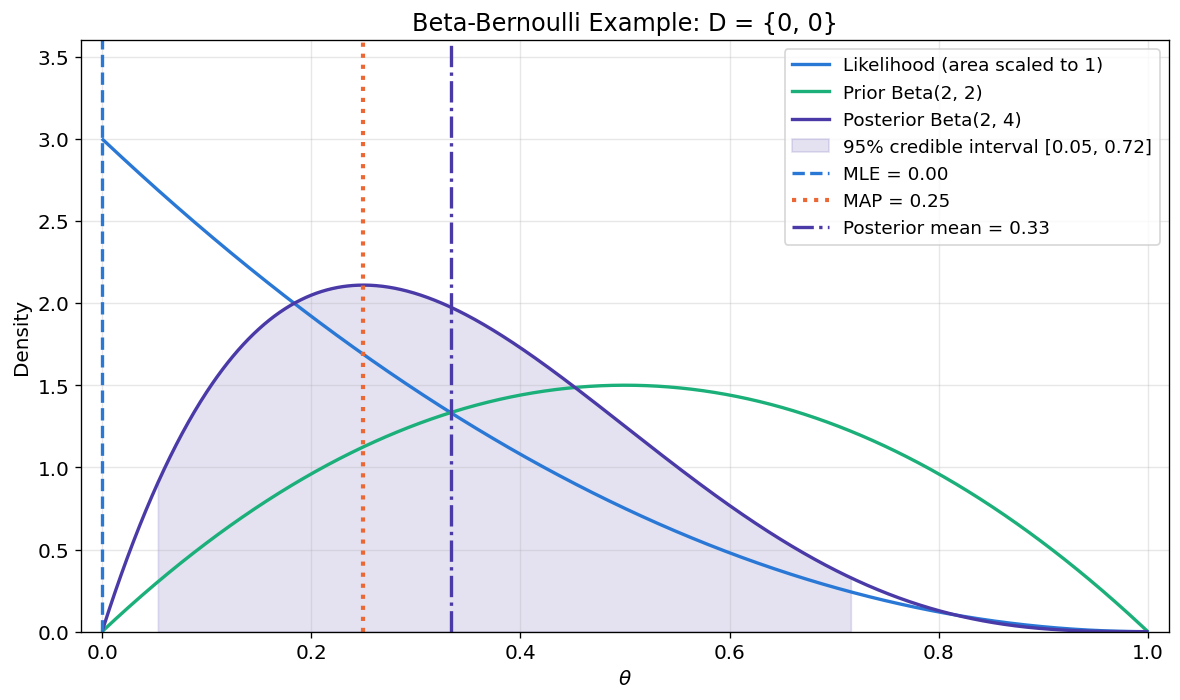

In [8]:
theta_grid = np.linspace(0.001, 0.999, 1200)

prior_density = beta.pdf(theta_grid, alpha0, beta0)
posterior_density = beta.pdf(theta_grid, alpha_post, beta_post)

# Likelihood theta^s (1 - theta)^f, scaled to area 1 so it fits on the density axis.
# Scaled this way it is exactly the Beta(s + 1, f + 1) density.
likelihood_theta = beta.pdf(theta_grid, successes + 1, failures + 1)

# 95% credible interval of the posterior: its 2.5% and 97.5% quantiles
ci_low, ci_high = beta.ppf([0.025, 0.975], alpha_post, beta_post)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(theta_grid, likelihood_theta, color=COL_MLE, linewidth=2,
        label="Likelihood (area scaled to 1)")
ax.plot(theta_grid, prior_density, color=COL_PRIOR, linewidth=2, label="Prior Beta(2, 2)")
ax.plot(theta_grid, posterior_density, color=COL_POST, linewidth=2, label="Posterior Beta(2, 4)")
in_ci = (theta_grid >= ci_low) & (theta_grid <= ci_high)
ax.fill_between(theta_grid, posterior_density, where=in_ci, color=COL_POST, alpha=0.15,
                label=f"95% credible interval [{ci_low:.2f}, {ci_high:.2f}]")

ax.axvline(theta_mle, color=COL_MLE, linestyle="--", linewidth=2, label=f"MLE = {theta_mle:.2f}")
ax.axvline(theta_map, color=COL_MAP, linestyle=":", linewidth=2.5, label=f"MAP = {theta_map:.2f}")
ax.axvline(
    theta_posterior_mean,
    color=COL_POST, linestyle="-.", linewidth=2,
    label=f"Posterior mean = {theta_posterior_mean:.2f}"
)

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0, 3.6)
ax.set_xlabel(r"$\theta$")
ax.set_ylabel("Density")
ax.set_title("Beta-Bernoulli Example: D = {0, 0}")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

Here the three numerical summaries are different:

$$
\hat{\theta}_{ML}=0
$$

$$
\hat{\theta}_{MAP}=0.25
$$

$$
E[\theta\mid D]=\frac{1}{3}.
$$

But full Bayesian estimation is **not just the posterior mean**.

Its actual result is the full posterior:

$$
p(\theta\mid D)=\text{Beta}(2,4).
$$

The posterior mean is only one useful summary of that distribution.

### 4.1 Same data, different priors

Keep $D=\{0,0\}$ and change only the prior. Beta$(1,1)$ is the flat (uniform) prior.

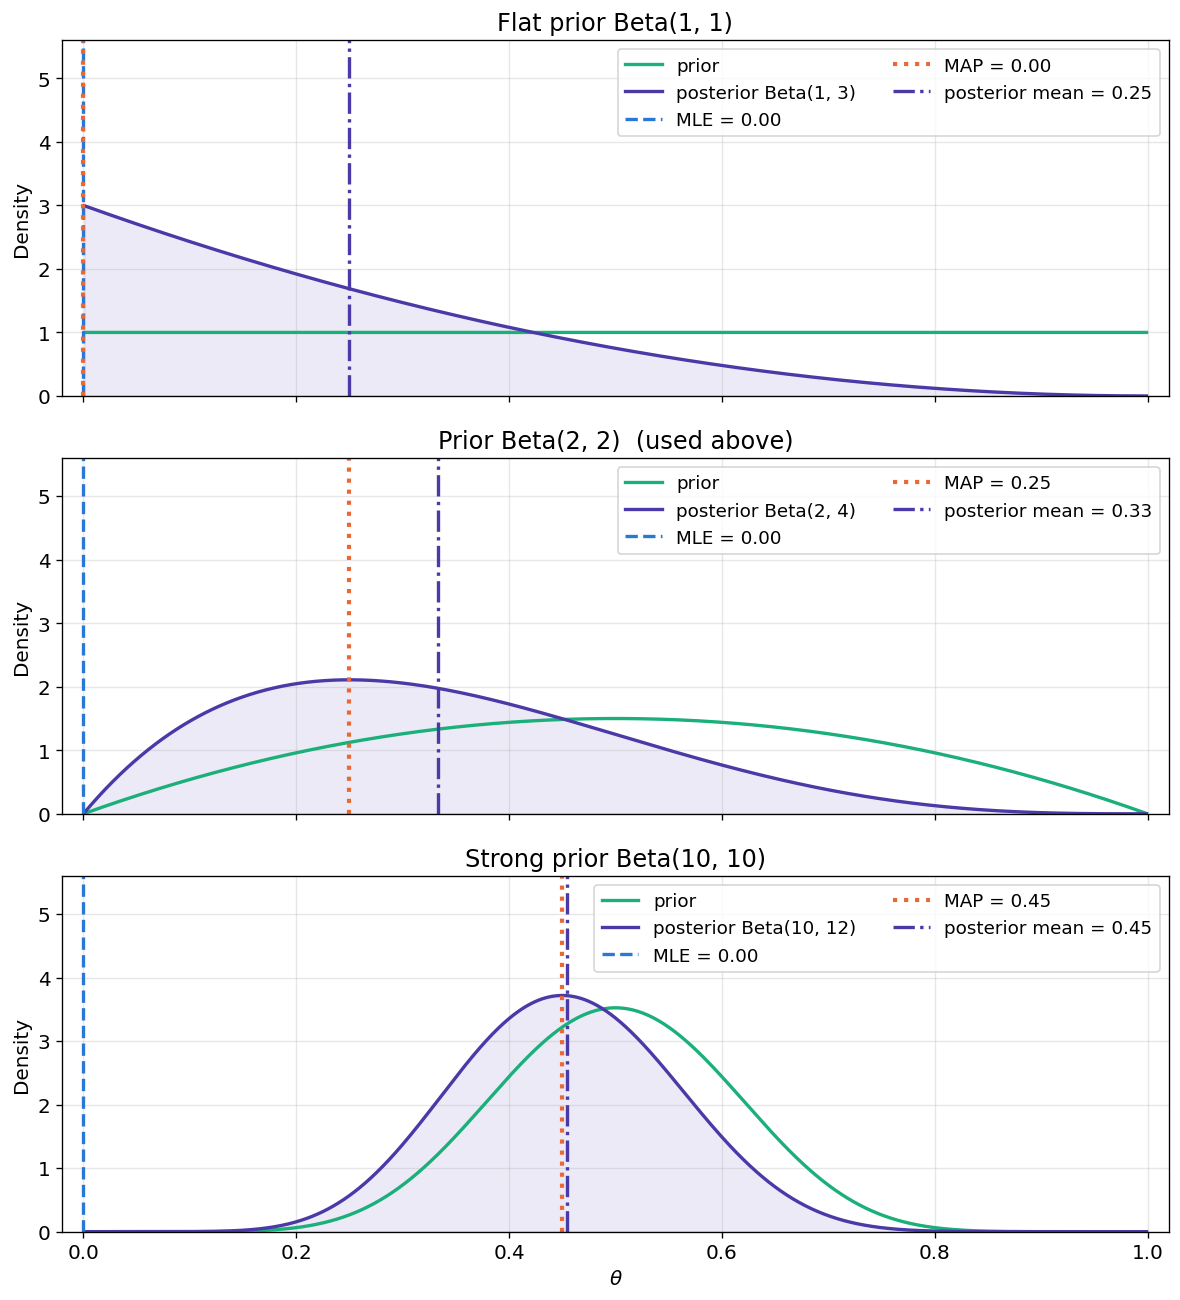

In [9]:
prior_cases = [
    (1, 1, "Flat prior Beta(1, 1)"),
    (2, 2, "Prior Beta(2, 2)  (used above)"),
    (10, 10, "Strong prior Beta(10, 10)"),
]

fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True, sharey=True)
for ax, (a0, b0, name) in zip(axes, prior_cases):
    a_n, b_n = a0 + successes, b0 + failures            # posterior Beta(a_n, b_n)
    t_map = (a_n - 1) / (a_n + b_n - 2)                 # mode of the Beta (0 when a_n = 1)
    t_mean = a_n / (a_n + b_n)
    post = beta.pdf(theta_grid, a_n, b_n)

    ax.plot(theta_grid, beta.pdf(theta_grid, a0, b0), color=COL_PRIOR, linewidth=2, label="prior")
    ax.plot(theta_grid, post, color=COL_POST, linewidth=2, label=f"posterior Beta({a_n}, {b_n})")
    ax.fill_between(theta_grid, post, color=COL_POST, alpha=0.1)
    ax.axvline(theta_mle, color=COL_MLE, linestyle="--", linewidth=2, label=f"MLE = {theta_mle:.2f}")
    ax.axvline(t_map, color=COL_MAP, linestyle=":", linewidth=2.5, label=f"MAP = {t_map:.2f}")
    ax.axvline(t_mean, color=COL_POST, linestyle="-.", linewidth=2,
               label=f"posterior mean = {t_mean:.2f}")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(0, 5.6)
    ax.set_title(name)
    ax.set_ylabel("Density")
    ax.legend(loc="upper right", ncol=2)
axes[-1].set_xlabel(r"$\theta$")
plt.tight_layout()
plt.show()

### What should we notice?

- **Flat prior:** the posterior is proportional to the likelihood, so MAP = MLE = 0 exactly. The posterior mean is still $1/4$: the full posterior says that small positive values of $\theta$ remain plausible. **MAP = MLE does not mean Bayes = MLE.**
- **Stronger prior:** for the MAP, Beta$(a,b)$ acts like $a-1$ extra successes and $b-1$ extra failures (for the posterior mean, $a$ and $b$). Beta$(10,10)$ is worth 18 extra flips, so it pulls hard toward $0.5$.

#### Animation: one coin flip at a time

Flips arrive one at a time from a coin with true $\theta=0.3$; the first two flips are the $D=\{0,0\}$ above. Top: the posterior after $n$ flips. Bottom: the three estimates so far, with the 95% credible interval.

Watch the start: after the first failures the MLE says $\theta=0$, i.e. a success is impossible, and with few flips every new flip moves it a lot. MAP and the posterior mean move more gradually, and the credible interval shrinks as $n$ grows.

In [10]:
theta_true = 0.3
rng_flips = np.random.default_rng(3)
# The first two flips are D = {0, 0} from above; the rest come from the true coin
flips = np.r_[0, 0, (rng_flips.random(48) < theta_true).astype(int)]

n_seq = np.arange(len(flips) + 1)            # n = 0, 1, ..., 50
s_seq = np.r_[0, np.cumsum(flips)]           # successes after n flips
a_seq = alpha0 + s_seq                       # posterior Beta(a, b) after n flips
b_seq = beta0 + (n_seq - s_seq)
mle_seq = s_seq / np.maximum(n_seq, 1)       # undefined at n = 0 (not drawn)
map_seq = (a_seq - 1) / (a_seq + b_seq - 2)
mean_seq = a_seq / (a_seq + b_seq)
lo_seq, hi_seq = beta.ppf([[0.025], [0.975]], a_seq, b_seq)

fig, (ax_p, ax_t) = plt.subplots(2, 1, figsize=(10, 9.5))
fig.subplots_adjust(left=0.09, right=0.97, hspace=0.42, top=0.92, bottom=0.07)


def update(k):
    nk = n_seq[k]

    # Top: the posterior after nk flips
    ax_p.cla()
    post_k = beta.pdf(theta_grid, a_seq[k], b_seq[k])
    ax_p.plot(theta_grid, prior_density, color=COL_PRIOR, linewidth=2, label="prior Beta(2, 2)")
    ax_p.plot(theta_grid, post_k, color=COL_POST, linewidth=2,
              label=f"posterior Beta({a_seq[k]:g}, {b_seq[k]:g})")
    ax_p.fill_between(theta_grid, post_k, color=COL_POST, alpha=0.1)
    if nk > 0:
        ax_p.axvline(mle_seq[k], color=COL_MLE, linestyle="--", linewidth=2,
                     label=f"MLE = {mle_seq[k]:.2f}")
    ax_p.axvline(map_seq[k], color=COL_MAP, linestyle=":", linewidth=2.5,
                 label=f"MAP = {map_seq[k]:.2f}")
    ax_p.axvline(mean_seq[k], color=COL_POST, linestyle="-.", linewidth=2,
                 label=f"posterior mean = {mean_seq[k]:.2f}")
    ax_p.axvline(theta_true, color="k", linewidth=1, label="true θ = 0.3")
    ax_p.set_xlim(-0.02, 1.02)
    ax_p.set_ylim(0, 7.5)
    ax_p.set_xlabel(r"$\theta$")
    ax_p.set_ylabel("Density")
    latest = "".join(map(str, flips[max(0, nk - 25):nk])) if nk else "(none yet)"
    ax_p.set_title(f"n = {nk}:  {s_seq[k]} successes, {nk - s_seq[k]} failures\n"
                   f"latest flips: {latest}")
    ax_p.legend(loc="upper right")

    # Bottom: the estimates so far
    ax_t.cla()
    ax_t.fill_between(n_seq[:k + 1], lo_seq[:k + 1], hi_seq[:k + 1], color=COL_POST,
                      alpha=0.15, label="95% credible interval")
    ax_t.plot(n_seq[1:k + 1], mle_seq[1:k + 1], "o-", color=COL_MLE, markersize=4,
              linewidth=1.5, label="MLE")
    ax_t.plot(n_seq[:k + 1], map_seq[:k + 1], color=COL_MAP, linewidth=2, label="MAP")
    ax_t.plot(n_seq[:k + 1], mean_seq[:k + 1], color=COL_POST, linestyle="-.", linewidth=2,
              label="posterior mean")
    ax_t.axhline(theta_true, color="k", linewidth=1, label="true θ")
    ax_t.set_xlim(0, len(flips))
    ax_t.set_ylim(-0.03, 1.03)
    ax_t.set_xlabel("number of flips n")
    ax_t.set_ylabel(r"Estimate of $\theta$")
    ax_t.set_title("Estimates as the flips arrive")
    ax_t.legend(loc="upper right", ncol=2)


# Every flip at the start (where things change fast), then larger steps
frames = list(range(0, 13)) + [14, 16, 18, 20] + list(range(24, 49, 4)) + [len(flips)]
show_animation(fig, update, frames=frames, interval=300)

## 5. Full Bayes keeps uncertainty that MAP discards

Suppose two posterior distributions have the same mode:

$$
\hat{\mu}_{MAP}=5.
$$

One posterior may be very narrow and another very wide.

If we keep only MAP, both answers look identical.

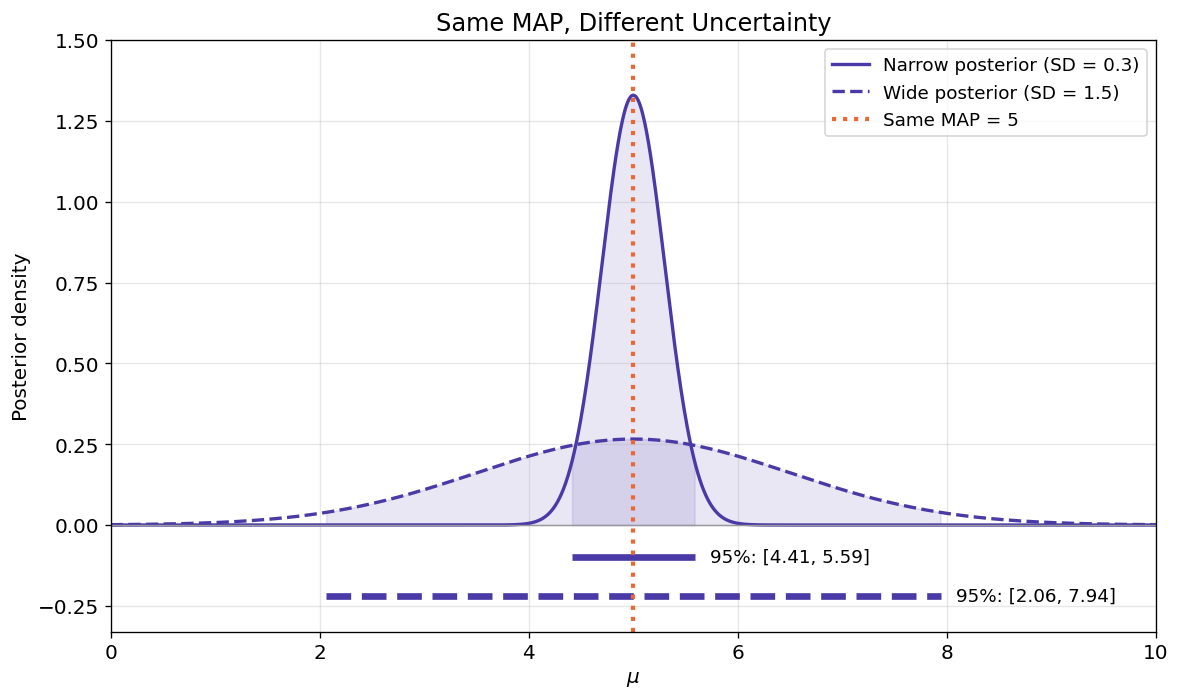

In [11]:
mu_grid5 = np.linspace(0, 10, 1000)
cases_5 = [("Narrow posterior", 0.3, "-"), ("Wide posterior", 1.5, "--")]

fig, ax = plt.subplots(figsize=(10, 6))
for j, (name, s, ls) in enumerate(cases_5):
    dens = norm.pdf(mu_grid5, loc=5, scale=s)
    lo, hi = norm.ppf([0.025, 0.975], loc=5, scale=s)
    ax.plot(mu_grid5, dens, color=COL_POST, linewidth=2, linestyle=ls,
            label=f"{name} (SD = {s})")
    ax.fill_between(mu_grid5, dens, where=(mu_grid5 >= lo) & (mu_grid5 <= hi),
                    color=COL_POST, alpha=0.12)
    # 95% interval as a bar below the axis
    y_bar = -0.1 - 0.12 * j
    ax.plot([lo, hi], [y_bar, y_bar], color=COL_POST, linewidth=4, linestyle=ls,
            solid_capstyle="butt")
    ax.text(hi + 0.15, y_bar, f"95%: [{lo:.2f}, {hi:.2f}]", va="center", fontsize=11)

ax.axvline(5, color=COL_MAP, linestyle=":", linewidth=2.5, label="Same MAP = 5")
ax.axhline(0, color="0.6", linewidth=0.8)
ax.set_xlim(0, 10)
ax.set_ylim(-0.33, 1.5)
ax.set_xlabel(r"$\mu$")
ax.set_ylabel("Posterior density")
ax.set_title("Same MAP, Different Uncertainty")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

MAP reports only

$$
\hat{\mu}_{MAP}=5.
$$

Full Bayes distinguishes:

- "the parameter is almost certainly near 5";
- "5 is the most likely value, but there is still large uncertainty."

This is one of the most important differences between MAP and Bayesian estimation.

## 6. Posterior predictive distribution

Bayesian estimation also changes how we make predictions.

A plug-in method uses one parameter estimate:

$$
p(x_{new}\mid\hat{\theta}).
$$

Full Bayesian prediction averages over the posterior:

$$
p(x_{new}\mid D)
=
\int
p(x_{new}\mid\theta)
p(\theta\mid D)
\,d\theta.
$$

For the Beta-Bernoulli example,

$$
P(x_{new}=1\mid D)
=
E[\theta\mid D]
=
\frac{\alpha_{post}}
{\alpha_{post}+\beta_{post}}.
$$

Even though MLE gives

$$
\hat{\theta}_{ML}=0,
$$

full Bayes does **not** conclude that a future success is impossible.

### 6.1 The predictive averages many plausible models

Return to the two posteriors of Section 5 and assume each observation is $x\sim\mathcal{N}(\mu,1)$. Draw 40 values $\mu_s$ from each posterior and plot the model $p(x\mid\mu_s)$ for each of them (thin lines). Their average is the posterior predictive, which for this model is

$$
p(x_{new}\mid D)=\mathcal{N}\big(x_{new}\mid 5,\ 1+s^2\big),
$$

where $s$ is the posterior SD. The MAP plug-in $\mathcal{N}(x_{new}\mid 5,1)$ ignores $s$, so it is the **same curve** for both posteriors.

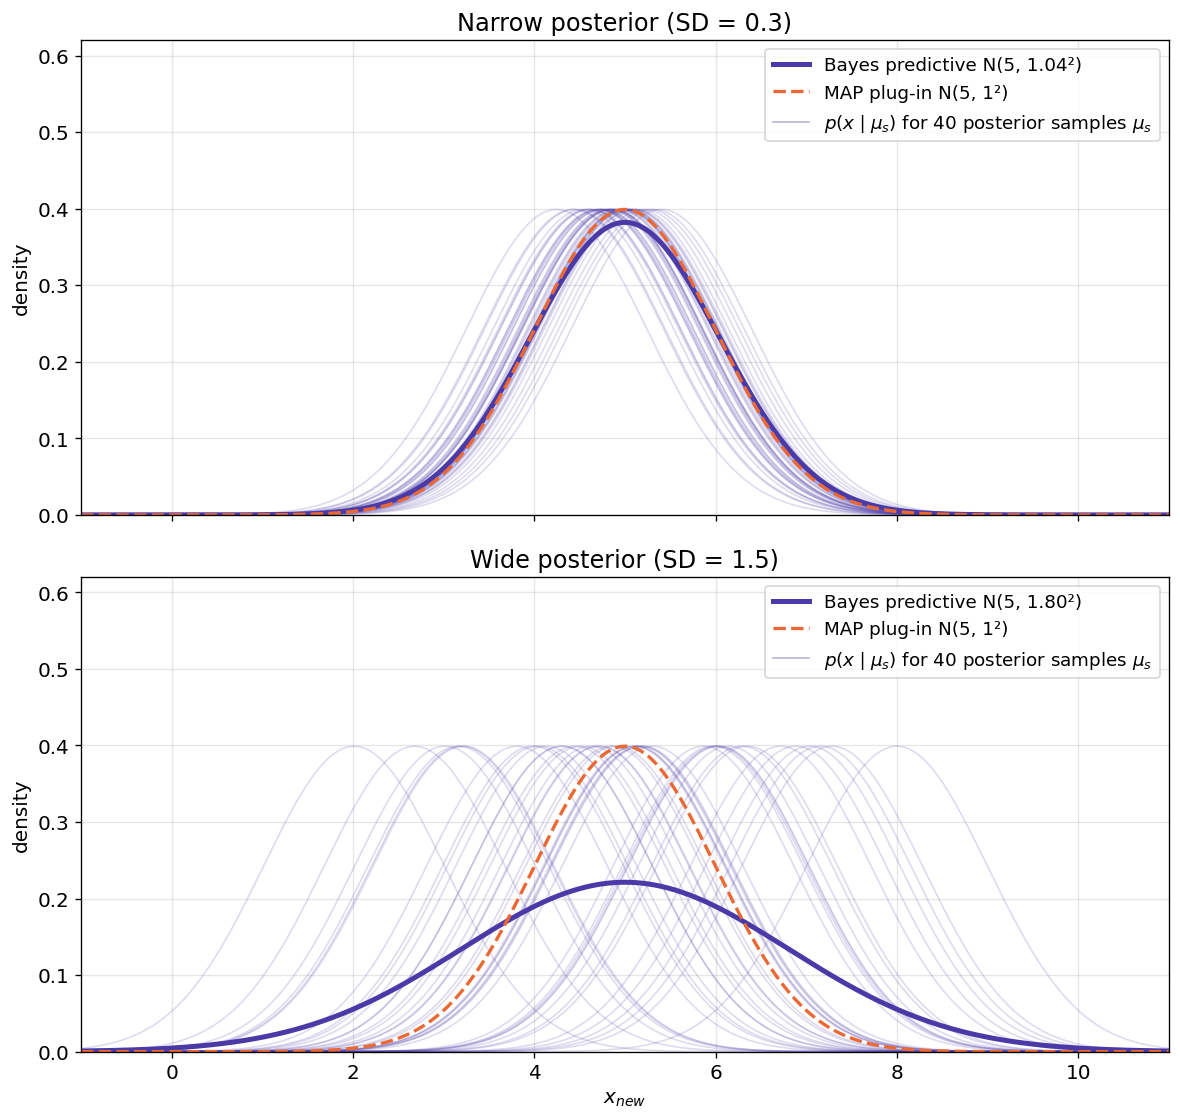

In [12]:
sigma_x = 1.0                                  # observation model: x ~ N(mu, 1)
x_new_grid = np.linspace(-1, 11, 600)
rng_spag = np.random.default_rng(7)

fig, axes = plt.subplots(2, 1, figsize=(10, 9.5), sharex=True, sharey=True)
for ax, (name, s, _) in zip(axes, cases_5):
    mu_samples = rng_spag.normal(5, s, size=40)          # 40 plausible values of mu
    for m in mu_samples:
        ax.plot(x_new_grid, norm.pdf(x_new_grid, m, sigma_x), color=COL_POST,
                alpha=0.18, linewidth=1)
    pred_sd = np.sqrt(sigma_x**2 + s**2)
    ax.plot(x_new_grid, norm.pdf(x_new_grid, 5, pred_sd), color=COL_POST, linewidth=3,
            label=f"Bayes predictive N(5, {pred_sd:.2f}²)")
    ax.plot(x_new_grid, norm.pdf(x_new_grid, 5, sigma_x), color=COL_MAP, linestyle="--",
            linewidth=2, label="MAP plug-in N(5, 1²)")
    # legend entry for the thin lines
    ax.plot([], [], color=COL_POST, alpha=0.4, linewidth=1,
            label=r"$p(x\mid\mu_s)$ for 40 posterior samples $\mu_s$")
    ax.set_xlim(-1, 11)
    ax.set_ylim(0, 0.62)
    ax.set_title(f"{name} (SD = {s})")
    ax.set_ylabel("density")
    ax.legend(loc="upper right")
axes[-1].set_xlabel(r"$x_{new}$")
plt.tight_layout()
plt.show()

With the narrow posterior all plausible models agree, and the plug-in is almost the same as the Bayesian predictive. With the wide posterior the models disagree, and the Bayesian predictive is wider: it adds the parameter uncertainty $s^2$ to the noise variance $1$.

### 6.2 Predicting more than one future trial

How many successes should we expect in the next $10$ trials?

- Plug-in: Binomial$(10,\hat{\theta})$ with $\hat{\theta}=0$ (MLE) or $\hat{\theta}=0.25$ (MAP).
- Bayes: average the Binomial over the posterior Beta$(2,4)$, which gives the **Beta-Binomial**$(10,2,4)$ distribution.

MLE plug-in: Binomial(10, 0)      mean = 0.00   SD = 0.00   P(0 successes) = 1.000
MAP plug-in: Binomial(10, 0.25)   mean = 2.50   SD = 1.37   P(0 successes) = 0.056
Bayes: Beta-Binomial(10, 2, 4)    mean = 3.33   SD = 2.25   P(0 successes) = 0.095


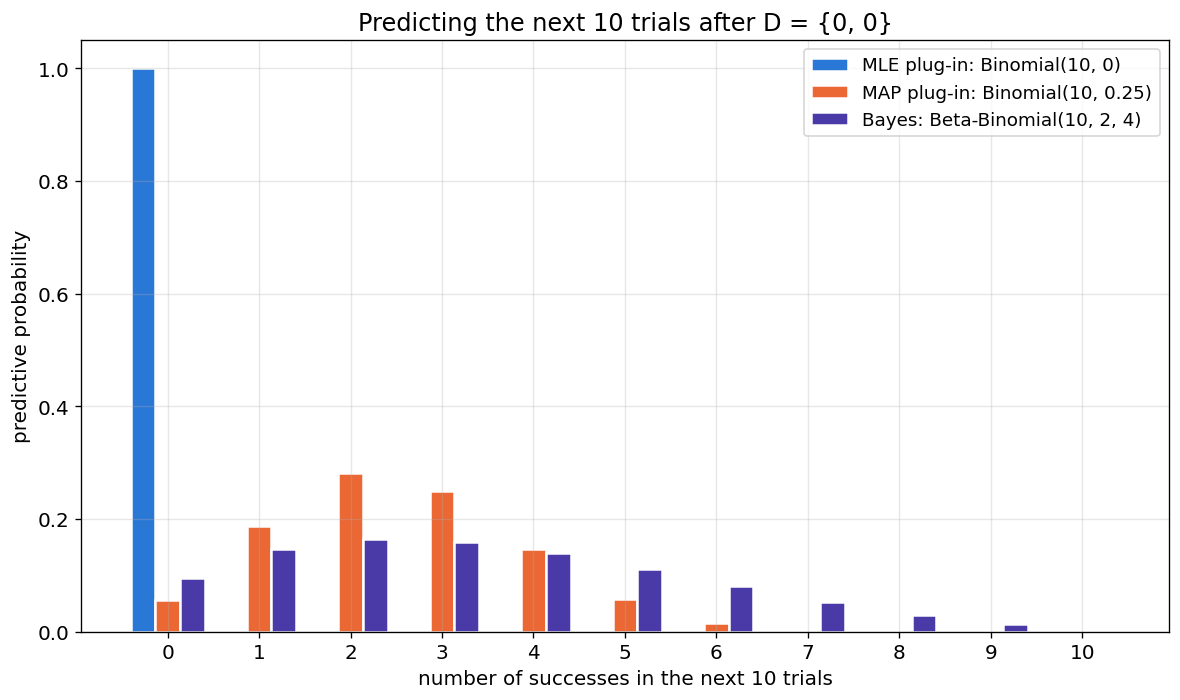

In [13]:
m_future = 10
k_vals = np.arange(m_future + 1)

predictives = [
    ("MLE plug-in: Binomial(10, 0)", binom.pmf(k_vals, m_future, theta_mle), COL_MLE),
    ("MAP plug-in: Binomial(10, 0.25)", binom.pmf(k_vals, m_future, theta_map), COL_MAP),
    ("Bayes: Beta-Binomial(10, 2, 4)",
     betabinom.pmf(k_vals, m_future, alpha_post, beta_post), COL_POST),
]

fig, ax = plt.subplots(figsize=(10, 6))
width = 0.27
for j, (name, pmf, col) in enumerate(predictives):
    ax.bar(k_vals + (j - 1) * width, pmf, width, color=col, edgecolor="white",
           linewidth=1.5, label=name)
    mean_k = (k_vals * pmf).sum()
    sd_k = np.sqrt(((k_vals - mean_k)**2 * pmf).sum())
    print(f"{name:33s} mean = {mean_k:.2f}   SD = {sd_k:.2f}   P(0 successes) = {pmf[0]:.3f}")

ax.set_xticks(k_vals)
ax.set_xlabel("number of successes in the next 10 trials")
ax.set_ylabel("predictive probability")
ax.set_title("Predicting the next 10 trials after D = {0, 0}")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

The MLE plug-in puts probability 1 on "zero successes in the next 10 trials". The Bayesian predictive is the widest of the three: besides the randomness of the flips it also includes the uncertainty about $\theta$, so compared with the MAP plug-in it puts more probability on $0$ successes **and** on large counts.

## 7. Categorical example: why zero probabilities matter

Suppose a categorical variable has three outcomes:

$$
A,\ B,\ C
$$

with observed counts

$$
[4,1,0].
$$

MLE estimates the probabilities directly from the observed frequencies.

In [14]:
counts = np.array([4, 1, 0])
labels = ["A", "B", "C"]

# MLE
p_mle = counts / counts.sum()

# Dirichlet(1,1,1) prior
alpha = np.ones(3)

# MAP = mode of the posterior Dirichlet(counts + alpha):
# (n_k + alpha_k - 1) / (N + sum(alpha) - K)
p_map = (counts + alpha - 1) / (counts.sum() + alpha.sum() - len(alpha))

# Posterior predictive
p_bayes = (counts + alpha) / (counts.sum() + alpha.sum())

print("MLE:")
for label, p in zip(labels, p_mle):
    print(f"P({label}) = {p:.3f}")

print("\nMAP (mode of the Dirichlet posterior):")
for label, p in zip(labels, p_map):
    print(f"P({label}) = {p:.3f}")

print("\nBayesian posterior predictive:")
for label, p in zip(labels, p_bayes):
    print(f"P({label}) = {p:.3f}")

MLE:
P(A) = 0.800
P(B) = 0.200
P(C) = 0.000

MAP (mode of the Dirichlet posterior):
P(A) = 0.800
P(B) = 0.200
P(C) = 0.000

Bayesian posterior predictive:
P(A) = 0.625
P(B) = 0.250
P(C) = 0.125


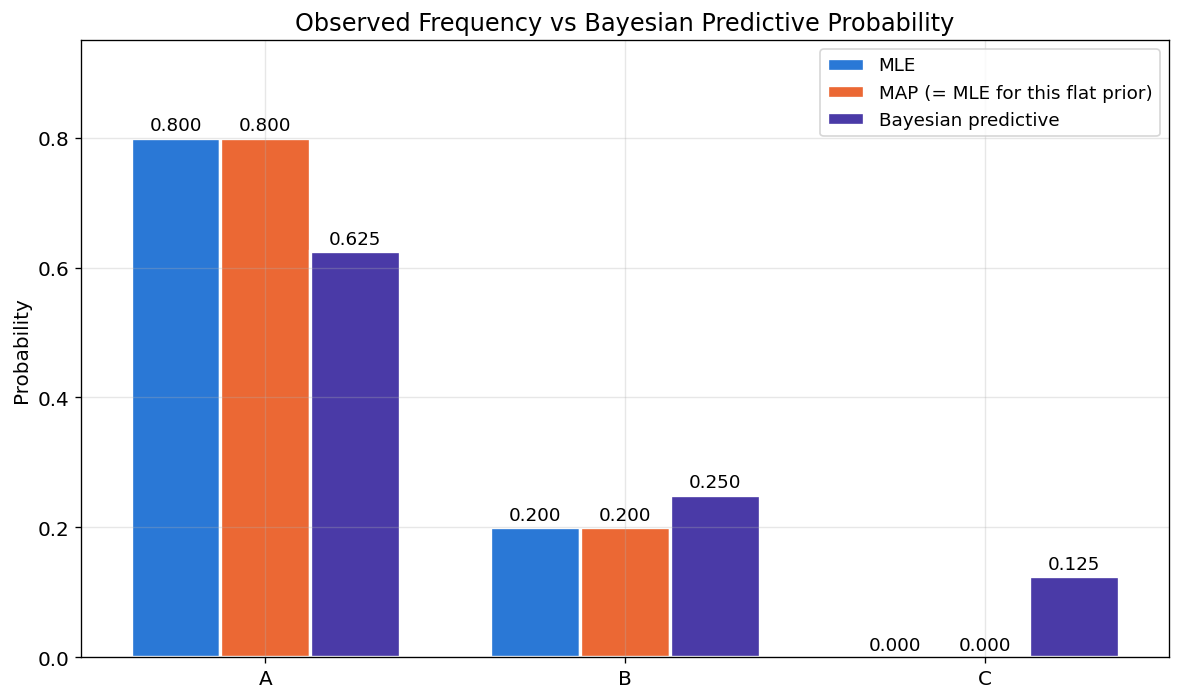

In [15]:
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bar_groups = [
    (p_mle, -width, COL_MLE, "MLE"),
    (p_map, 0.0, COL_MAP, "MAP (= MLE for this flat prior)"),
    (p_bayes, width, COL_POST, "Bayesian predictive"),
]
for values, shift, col, name in bar_groups:
    rects = ax.bar(x + shift, values, width, color=col, edgecolor="white", linewidth=2,
                   label=name)
    ax.bar_label(rects, fmt="%.3f", fontsize=11, padding=2)

ax.set_xticks(x, labels)
ax.set_ylim(0, 0.95)
ax.set_ylabel("Probability")
ax.set_title("Observed Frequency vs Bayesian Predictive Probability")
ax.legend()
plt.tight_layout()
plt.show()

MLE gives

$$
P(C)=0.
$$

With the flat Dirichlet$(1,1,1)$ prior, the MAP is still the observed frequency, so it also says $P(C)=0$. Only the Bayesian prediction, which averages over the posterior, gives a nonzero value.

This is the idea behind plus-one smoothing in the categorical case.

## 8. Real problem: predicting batting averages from 45 at-bats

April 1970, after 45 at-bats: Roberto Clemente is hitting **.400** and Max Alvis only **.156**. What will each of them hit over the rest of the season?

Efron & Morris (1975) recorded the first 45 at-bats of 18 Major League players in 1970, together with their batting average over the **rest of the season** (70 to 591 more at-bats). So we can check every method against what actually happened.

| Lecture concept | What it is here |
|---|---|
| Parameter $\theta_j$ | player $j$'s true hitting ability: the probability of a hit in one at-bat |
| Data $D_j$ | $y_j$ hits in the first 45 at-bats |
| Likelihood | $y_j\sim\text{Binomial}(45,\theta_j)$, the model of Section 4 |
| Prior | Beta$(a,b)$: what hitting abilities look like across the league |
| MLE | the raw average $y_j/45$ |
| MAP | the peak of the posterior Beta$(a+y_j,\ b+45-y_j)$ |
| Full Bayes | the whole posterior; for prediction, the Beta-Binomial predictive of the rest of the season (Section 6.2) |
| Ground truth | the player's actual average over the rest of the season |

**The prior.** Before 1970, nobody had hit .400 over a full season since 1941, and the true abilities of regular players lie mostly within about $\pm .06$ of the league average. We encode this (an assumed prior, for illustration) as a Beta prior with mean $.265$, the average of the 18 players, and SD $.03$. This prior is worth $a+b\approx 216$ at-bats, so the 45 real at-bats get only $45/(45+216)\approx 17\%$ of the weight (compare Section 3.2).

In [16]:
# Efron & Morris (1975): 18 players, 1970 season
# (data file: efron-morris-75-data.tsv in the stan-dev/example-models repository)
players = ["Clemente", "F. Robinson", "F. Howard", "Johnstone", "Berry", "Spencer",
           "Kessinger", "Alvarado", "Santo", "Swaboda", "Petrocelli", "Rodriguez",
           "Scott", "Unser", "Williams", "Campaneris", "Munson", "Alvis"]
hits_45 = np.array([18, 17, 16, 15, 14, 14, 13, 12, 11, 11, 10, 10, 10, 10, 10, 9, 8, 7])
rest_ab = np.array([367, 426, 521, 275, 418, 466, 586, 138, 510, 200,
                    538, 186, 435, 277, 591, 558, 408, 70])
rest_hits = np.array([127, 127, 144, 61, 114, 126, 155, 29, 137, 46,
                      142, 42, 132, 73, 195, 159, 129, 14])
rest_avg = rest_hits / rest_ab              # what actually happened

n_ab = 45
avg_mle = hits_45 / n_ab                    # MLE: the raw batting average

# Prior Beta(a, b): mean = average of the 18 players, SD = 0.03 (assumed)
prior_mean, prior_sd = avg_mle.mean(), 0.03
strength = prior_mean * (1 - prior_mean) / prior_sd**2 - 1      # a + b
a_bb, b_bb = prior_mean * strength, (1 - prior_mean) * strength

# Posterior Beta(a + y, b + 45 - y) for every player, and its peak
A_post, B_post = a_bb + hits_45, b_bb + n_ab - hits_45
avg_map = (A_post - 1) / (A_post + B_post - 2)

# 95% predictive interval for the rest-of-season average (Beta-Binomial, Section 6.2)
pred_lo = betabinom.ppf(0.025, rest_ab, A_post, B_post) / rest_ab
pred_hi = betabinom.ppf(0.975, rest_ab, A_post, B_post) / rest_ab

print(f"Prior Beta({a_bb:.1f}, {b_bb:.1f}): mean {prior_mean:.3f}, "
      f"worth a + b = {strength:.0f} at-bats")
print(f"Weight on the 45 real at-bats: {n_ab / (n_ab + strength):.0%}\n")
for j in [0, len(players) - 1]:
    print(f"{players[j]:9s} MLE {avg_mle[j]:.3f} -> MAP {avg_map[j]:.3f}"
          f"    rest of season: {rest_avg[j]:.3f}")

Prior Beta(57.2, 158.4): mean 0.265, worth a + b = 216 at-bats
Weight on the 45 real at-bats: 17%

Clemente  MLE 0.400 -> MAP 0.287    rest of season: 0.346
Alvis     MLE 0.156 -> MAP 0.245    rest of season: 0.200


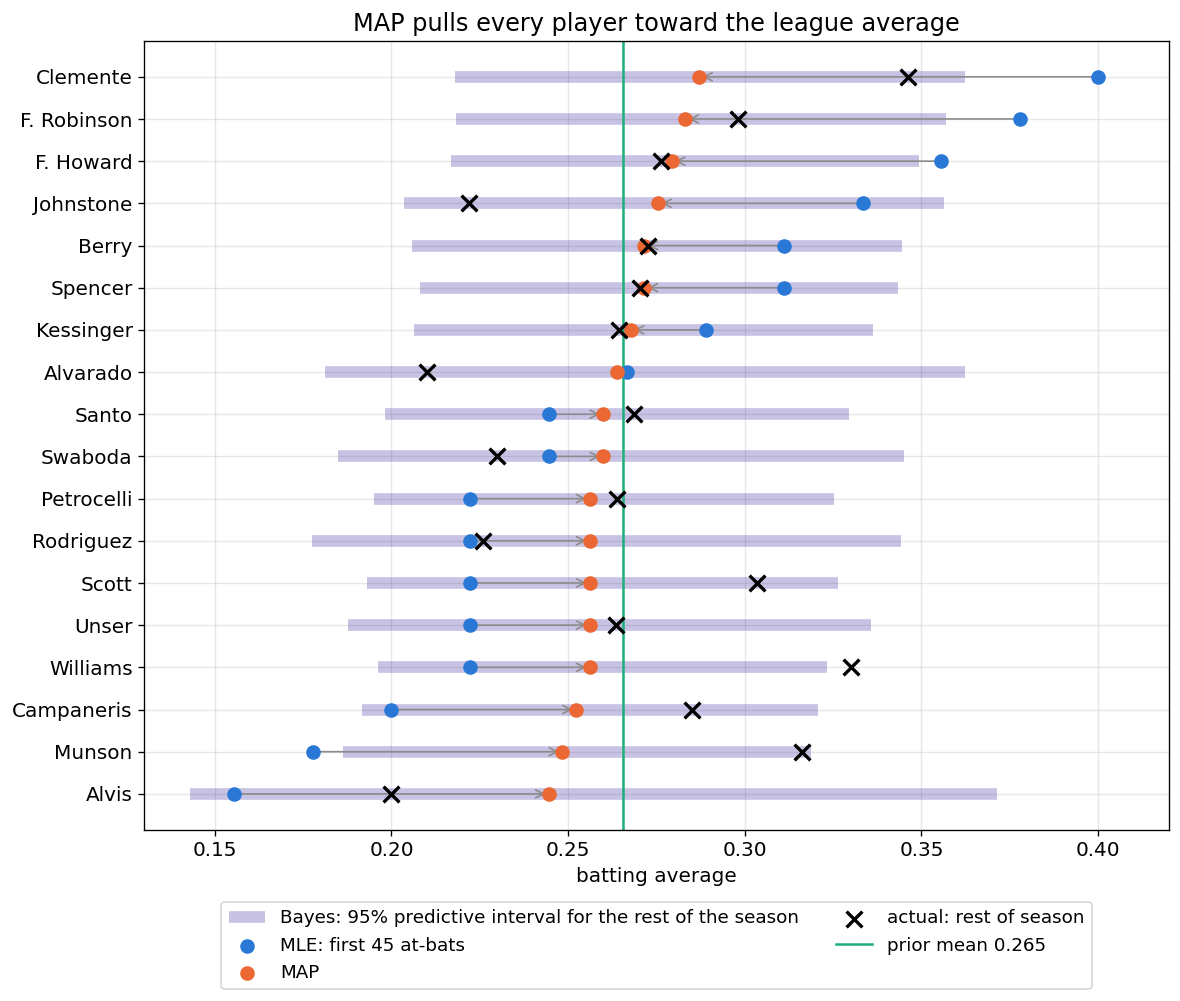

In [17]:
rows = np.arange(len(players))[::-1]        # row of each player: Clemente at the top

fig, ax = plt.subplots(figsize=(10, 8.5))
ax.hlines(rows, pred_lo, pred_hi, color=COL_POST, linewidth=7, alpha=0.3,
          label="Bayes: 95% predictive interval for the rest of the season")
for r, lo_mle, hi_map in zip(rows, avg_mle, avg_map):
    ax.annotate("", xy=(hi_map, r), xytext=(lo_mle, r),
                arrowprops=dict(arrowstyle="->", color="0.55", lw=1))
ax.scatter(avg_mle, rows, s=60, color=COL_MLE, zorder=4, label="MLE: first 45 at-bats")
ax.scatter(avg_map, rows, s=60, color=COL_MAP, zorder=4, label="MAP")
ax.scatter(rest_avg, rows, s=90, marker="x", color="k", linewidth=2, zorder=5,
           label="actual: rest of season")
ax.axvline(prior_mean, color=COL_PRIOR, linewidth=1.5, label=f"prior mean {prior_mean:.3f}")

ax.set_yticks(rows, players)
ax.set_xlim(0.13, 0.42)
ax.set_xlabel("batting average")
ax.set_title("MAP pulls every player toward the league average")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2)
plt.tight_layout()
plt.show()

### Did the prior help? Check against the rest of the season

- **Point estimates:** compare the squared error of the MLE and the MAP with the actual rest-of-season averages.
- **Intervals:** the actual average is itself based on a limited number of at-bats, so it is compared with a **predictive** interval (Section 6). For the MLE, the plug-in version is Binomial$(m_j,\hat{\theta}_{ML})$ for the $m_j$ remaining at-bats, which ignores the uncertainty about $\theta_j$.

In [18]:
sse_mle = np.sum((avg_mle - rest_avg)**2)
sse_map = np.sum((avg_map - rest_avg)**2)
closer = np.sum(np.abs(avg_map - rest_avg) < np.abs(avg_mle - rest_avg))

# 95% plug-in predictive interval from the MLE: Binomial(m_j, MLE)
mle_lo = binom.ppf(0.025, rest_ab, avg_mle) / rest_ab
mle_hi = binom.ppf(0.975, rest_ab, avg_mle) / rest_ab
inside_bayes = (rest_avg >= pred_lo) & (rest_avg <= pred_hi)
inside_mle = (rest_avg >= mle_lo) & (rest_avg <= mle_hi)

print(f"Total squared error:  MLE {sse_mle:.4f}   MAP {sse_map:.4f}"
      f"   ({sse_mle / sse_map:.1f} times smaller)")
print(f"MAP is closer than the MLE for {closer} of {len(players)} players\n")
print("Actual rest-of-season average inside the 95% predictive interval:")
print(f"  Bayes (Beta-Binomial):   {inside_bayes.sum()} of {len(players)}")
print(f"  MLE plug-in (Binomial):  {inside_mle.sum()} of {len(players)}")

Total squared error:  MLE 0.0857   MAP 0.0268   (3.2 times smaller)
MAP is closer than the MLE for 14 of 18 players

Actual rest-of-season average inside the 95% predictive interval:
  Bayes (Beta-Binomial):   17 of 18
  MLE plug-in (Binomial):  9 of 18
